# Experiment 4 — Binary Classification using Linear and Kernel-Based Models

**Course:** ICS1512 – Machine Learning Algorithms Laboratory

**Aim:** To classify emails as spam or ham using Logistic Regression and Support Vector Machine (SVM) classifiers, and to study how hyperparameter tuning (regularization strength, kernel choice, etc.) affects classification performance.

**Dataset:** UCI Spambase dataset (also mirrored on Kaggle), 4,601 emails, 57 numeric features (word frequencies, character frequencies, capital-letter run lengths) and a binary label, `is_spam` (1 = spam, 0 = ham). This is the real dataset, downloaded and used as-is, not a synthetic stand-in.

The pipeline follows the steps from the lab manual: load → preprocess → EDA → split → baseline Logistic Regression → tune Logistic Regression → baseline SVM (all kernels) → tune SVM → evaluate → 5-fold cross validation → compare.

In [1]:
import time
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

**What this cell does:** imports everything we need for the whole notebook in one place, `pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for plots, and the scikit-learn pieces for preprocessing, splitting, Logistic Regression, SVM, grid search and the evaluation metrics the manual asks for (accuracy, precision, recall, F1).

In [2]:
def load_and_preprocess(file_path):
    """
    Generic function to load and preprocess any CSV dataset.

    Steps:
    1. Load dataset
    2. Remove duplicate rows
    3. Remove completely empty rows and columns
    4. Replace common missing value symbols
    5. Remove leading/trailing spaces
    6. Convert numeric-looking strings to numeric
    7. Handle missing values
    8. Encode categorical columns
    9. Standardize numerical feature columns (excluding target)

    Returns:
        Preprocessed DataFrame
    """

    # ==========================
    # Load Dataset
    # ==========================
    df = pd.read_csv(file_path)

    print("=" * 60)
    print("DATASET LOADED SUCCESSFULLY")
    print("=" * 60)
    print("Original Shape:", df.shape)

    # ==========================
    # Remove Duplicate Rows
    # ==========================
    duplicates = df.duplicated().sum()
    df.drop_duplicates(inplace=True)

    # ==========================
    # Remove Completely Empty Rows & Columns
    # ==========================
    df.dropna(axis=0, how="all", inplace=True)
    df.dropna(axis=1, how="all", inplace=True)

    # ==========================
    # Replace Common Missing Value Symbols
    # ==========================
    df.replace(["?", "NA", "N/A", "", "null", "NULL"], pd.NA, inplace=True)

    # ==========================
    # Remove Extra Spaces
    # ==========================
    for col in df.select_dtypes(include=["object", "string"]).columns:
        df[col] = df[col].str.strip()

    # ==========================
    # Convert Numeric Strings
    # ==========================
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except (ValueError, TypeError):
            pass

    # ==========================
    # Handle Missing Values
    # ==========================
    for col in df.columns:

        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())

        else:
            mode = df[col].mode()

            if not mode.empty:
                df[col] = df[col].fillna(mode[0])

    # ==========================
    # Encode Categorical Columns
    # ==========================
    categorical_cols = df.select_dtypes(include=["object", "string"]).columns

    for col in categorical_cols:
        encoder = LabelEncoder()
        df[col] = encoder.fit_transform(df[col].astype(str))

    # ==========================
    # Standardize Numerical Columns
    # ==========================
    numeric_cols = df.select_dtypes(include="number").columns.tolist()

    if len(numeric_cols) > 1:

        feature_cols = numeric_cols[:-1]

        scaler = StandardScaler()
        df[feature_cols] = scaler.fit_transform(df[feature_cols])

    # ==========================
    # Summary
    # ==========================
    print("\nPreprocessing Completed Successfully!")
    print("Final Shape:", df.shape)
    print("Duplicate Rows Removed:", duplicates)
    print("Categorical Columns Encoded:", len(categorical_cols))

    if len(numeric_cols) > 1:
        print("Numerical Features Standardized:", len(feature_cols))

    return df

**What this cell does:** this is the same generic `load_and_preprocess()` function used in Experiment 1, reused here as-is since it already fits this dataset well. It loads the CSV, drops duplicate rows, cleans up common missing-value symbols, fills anything missing with the median (numeric) or mode (categorical), label-encodes any text columns, and standardizes every numeric feature column except the last one (assumed to be the target). Spambase is a fully numeric dataset with a clean binary target as the last column, so this function is a direct fit and did not need to be modified.

In [3]:
def perform_eda(df):
    """
    Generic EDA function.
    Generates a 3x4 figure containing 12 EDA plots.
    """

    numeric_cols = df.select_dtypes(include=np.number).columns
    categorical_cols = df.select_dtypes(exclude=np.number).columns

    fig, axes = plt.subplots(3, 4, figsize=(24, 18))
    axes = axes.flatten()

    # 1 Missing Values
    sns.heatmap(df.isnull(), cbar=False, cmap="viridis", ax=axes[0])
    axes[0].set_title("Missing Values")

    # 2 Correlation Heatmap
    if len(numeric_cols) > 1:
        sns.heatmap(df[numeric_cols].corr(),
                    annot=False,
                    cmap="coolwarm",
                    ax=axes[1])
        axes[1].set_title("Correlation Heatmap")
    else:
        axes[1].text(0.5,0.5,"Not enough numeric columns",ha="center")
        axes[1].set_title("Correlation Heatmap")

    # 3 Histogram
    if len(numeric_cols):
        sns.histplot(df[numeric_cols[0]], kde=True, ax=axes[2])
        axes[2].set_title(f"Histogram ({numeric_cols[0]})")

    # 4 Scatter Plot
    if len(numeric_cols) > 1:
        sns.scatterplot(x=df[numeric_cols[0]],
                        y=df[numeric_cols[1]],
                        ax=axes[3])
        axes[3].set_title("Scatter Plot")

    # 5 Box Plot
    if len(numeric_cols):
        sns.boxplot(y=df[numeric_cols[0]], ax=axes[4])
        axes[4].set_title("Box Plot")

    # 6 Bar Chart
    if len(categorical_cols):
        df[categorical_cols[0]].value_counts().plot(kind="bar", ax=axes[5])
        axes[5].set_title("Bar Chart")
    else:
        axes[5].text(0.5,0.5,"No categorical columns",ha="center")
        axes[5].set_title("Bar Chart")

    # 7 Pie Chart
    if len(categorical_cols):
        df[categorical_cols[0]].value_counts().plot(kind="pie",
                                                    autopct="%1.1f%%",
                                                    ax=axes[6])
        axes[6].set_ylabel("")
        axes[6].set_title("Pie Chart")
    else:
        axes[6].text(0.5,0.5,"No categorical columns",ha="center")
        axes[6].set_title("Pie Chart")

    # 8 Violin Plot
    if len(numeric_cols):
        sns.violinplot(y=df[numeric_cols[0]], ax=axes[7])
        axes[7].set_title("Violin Plot")

    # 9 Density Plot
    if len(numeric_cols):
        sns.kdeplot(df[numeric_cols[0]], fill=True, ax=axes[8])
        axes[8].set_title("Density Plot")

    # 10 Regression Plot
    if len(numeric_cols) > 1:
        sns.regplot(x=df[numeric_cols[0]],
                    y=df[numeric_cols[1]],
                    ax=axes[9])
        axes[9].set_title("Regression Plot")

    # 11 Strip Plot
    if len(numeric_cols):
        sns.stripplot(y=df[numeric_cols[0]], ax=axes[10])
        axes[10].set_title("Strip Plot")

    # 12 ECDF Plot
    if len(numeric_cols):
        sns.ecdfplot(df[numeric_cols[0]], ax=axes[11])
        axes[11].set_title("ECDF Plot")

    plt.tight_layout()
    plt.show()

    print("="*60)
    print("DATASET SUMMARY")
    print("="*60)
    print("\nShape:", df.shape)

    print("\nData Types")
    print(df.dtypes)

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nSummary Statistics")
    display(df.describe(include="all"))

**What this cell does:** the same generic `perform_eda()` function from Experiment 1, reused unchanged. It builds a 3x4 grid of 12 standard plots (missing values, correlation heatmap, histogram, scatter, box, bar, pie, violin, density, regression, strip, ECDF) plus a printed summary. One thing worth flagging honestly: since Spambase has no categorical columns (`is_spam` is stored as an integer 0/1, not a category), the bar and pie chart panels will just say "No categorical columns", they were designed for datasets with text/category columns. That is exactly why the next cell adds a couple of extra, dataset-specific plots (class balance and top spam-indicating features) that this generic function was not built to show.

In [4]:
df = load_and_preprocess("datasets/spambase.csv")
df.head()

DATASET LOADED SUCCESSFULLY
Original Shape: (4601, 58)

Preprocessing Completed Successfully!
Final Shape: (4210, 58)
Duplicate Rows Removed: 391
Categorical Columns Encoded: 0
Numerical Features Standardized: 57


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_paren,char_freq_bracket,char_freq_exclaim,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
0,-0.347922,1.161025,0.675889,-0.046644,-0.007737,-0.350205,-0.295731,-0.263265,-0.325617,-0.378366,...,-0.160010,-0.525294,-0.164364,0.589246,-0.317325,-0.105071,-0.049117,0.044398,-0.021310,1
1,0.352150,0.368433,0.404391,-0.046644,-0.269470,0.664297,0.232922,-0.092630,-0.325617,1.053337,...,-0.160010,-0.043936,-0.164364,0.107759,0.433676,0.005053,-0.008143,0.244841,1.191142,1
2,-0.147901,-0.248027,0.811639,-0.046644,1.315470,0.338207,0.182574,0.029252,1.943000,0.002406,...,-0.120407,-0.003822,-0.164364,-0.006090,0.450365,-0.082129,0.133876,2.169089,3.181179,1
3,-0.347922,-0.248027,-0.565245,-0.046644,0.443026,-0.350205,0.484661,1.272445,0.773244,0.581180,...,-0.160010,-0.025702,-0.164364,-0.170935,-0.317325,-0.105071,-0.055724,-0.060834,-0.161954,1
4,-0.347922,-0.248027,-0.565245,-0.046644,0.443026,-0.350205,0.484661,1.272445,0.773244,0.581180,...,-0.160010,-0.032996,-0.164364,-0.173306,-0.317325,-0.105071,-0.055724,-0.060834,-0.161954,1


**What this cell does:** loads the real Spambase CSV through the shared preprocessing pipeline. Since Spambase is already numeric and clean (no missing values, no text columns), the main visible effect here is standardization of all 57 feature columns, `is_spam` itself is left as 0/1 since it is the last column and gets treated as the target.

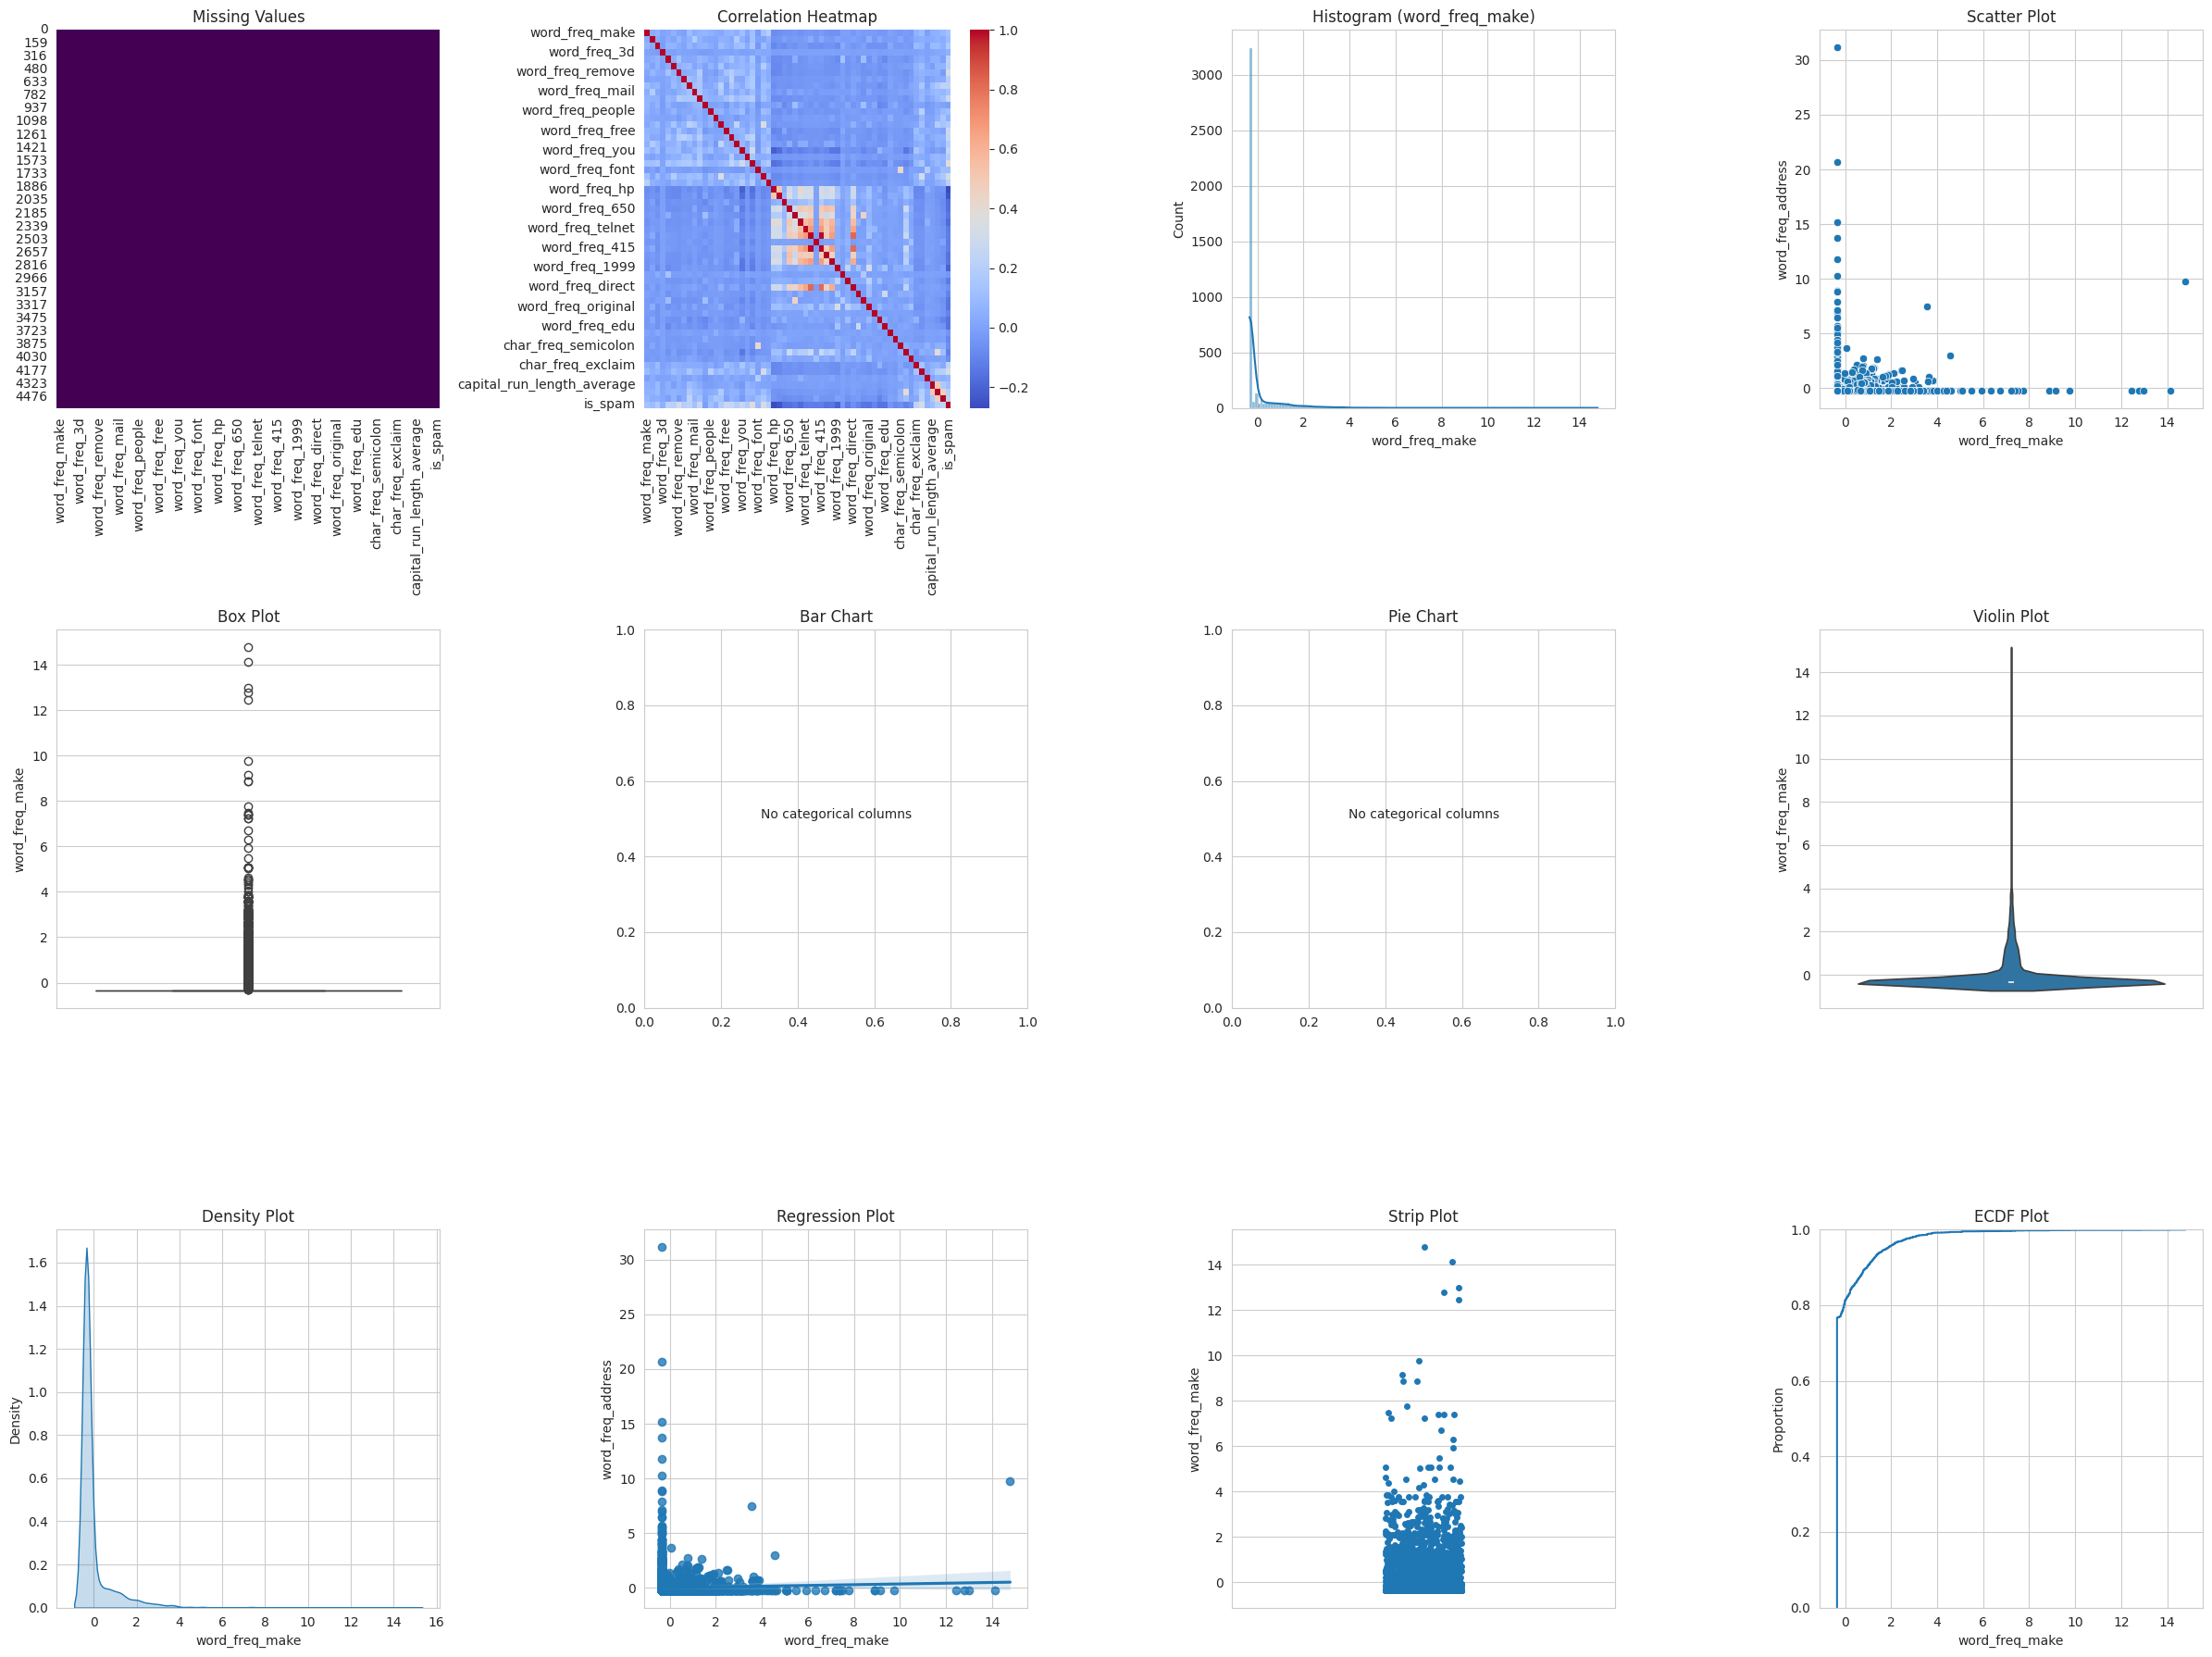

DATASET SUMMARY

Shape: (4210, 58)

Data Types
word_freq_make                float64
word_freq_address             float64
word_freq_all                 float64
word_freq_3d                  float64
word_freq_our                 float64
word_freq_over                float64
word_freq_remove              float64
word_freq_internet            float64
word_freq_order               float64
word_freq_mail                float64
word_freq_receive             float64
word_freq_will                float64
word_freq_people              float64
word_freq_report              float64
word_freq_addresses           float64
word_freq_free                float64
word_freq_business            float64
word_freq_email               float64
word_freq_you                 float64
word_freq_credit              float64
word_freq_your                float64
word_freq_font                float64
word_freq_000                 float64
word_freq_money               float64
word_freq_hp                  float64
wor

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_paren,char_freq_bracket,char_freq_exclaim,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
count,4.210000e+03,4.210000e+03,4.210000e+03,4210.000000,4.210000e+03,4.210000e+03,4210.000000,4.210000e+03,4210.000000,4.210000e+03,...,4210.000000,4.210000e+03,4.210000e+03,4.210000e+03,4.210000e+03,4.210000e+03,4.210000e+03,4.210000e+03,4.210000e+03,4210.000000
mean,4.725700e-17,1.350200e-17,2.700400e-17,0.000000,4.050600e-17,-1.350200e-17,0.000000,-1.350200e-17,0.000000,-8.776300e-17,...,0.000000,-6.751000e-18,1.350200e-17,-2.700400e-17,-2.700400e-17,2.700400e-17,-1.350200e-17,-1.350200e-17,-2.700400e-17,0.398812
std,1.000119e+00,1.000119e+00,1.000119e+00,1.000119,1.000119e+00,1.000119e+00,1.000119,1.000119e+00,1.000119,1.000119e+00,...,1.000119,1.000119e+00,1.000119e+00,1.000119e+00,1.000119e+00,1.000119e+00,1.000119e+00,1.000119e+00,1.000119e+00,0.489712
min,-3.479216e-01,-2.480275e-01,-5.652450e-01,-0.046644,-4.730399e-01,-3.502046e-01,-0.295731,-2.632646e-01,-0.325617,-3.783664e-01,...,-0.160010,-5.252942e-01,-1.643641e-01,-3.334068e-01,-3.173253e-01,-1.050711e-01,-1.322705e-01,-2.562653e-01,-4.691088e-01,0.000000
25%,-3.479216e-01,-2.480275e-01,-5.652450e-01,-0.046644,-4.730399e-01,-3.502046e-01,-0.295731,-2.632646e-01,-0.325617,-3.783664e-01,...,-0.160010,-5.252942e-01,-1.643641e-01,-3.334068e-01,-3.173253e-01,-1.050711e-01,-1.133376e-01,-2.261989e-01,-4.060613e-01,0.000000
50%,-3.479216e-01,-2.480275e-01,-5.652450e-01,-0.046644,-4.730399e-01,-3.502046e-01,-0.295731,-2.632646e-01,-0.325617,-3.783664e-01,...,-0.160010,-2.590883e-01,-1.643641e-01,-3.144319e-01,-3.173253e-01,-1.050711e-01,-9.313751e-02,-1.861104e-01,-3.066403e-01,0.000000
75%,-3.479216e-01,-2.480275e-01,2.880349e-01,-0.046644,1.231299e-01,-3.502046e-01,-0.295731,-2.632646e-01,-0.325617,-8.897950e-02,...,-0.160010,1.821569e-01,-1.643641e-01,5.913558e-02,-9.619715e-02,-1.050711e-01,-5.060267e-02,-4.078958e-02,-2.818053e-02,1.000000
max,1.478696e+01,3.119145e+01,9.325045e+00,31.609920,1.406769e+01,2.095434e+01,18.005710,2.681886e+01,18.319574,2.731139e+01,...,17.206130,3.503689e+01,3.843832e+01,3.818318e+01,2.472857e+01,4.538756e+01,3.310208e+01,4.979423e+01,2.513787e+01,1.000000


In [5]:
perform_eda(df)

**What this cell does:** runs the generic EDA grid on the preprocessed Spambase data. The missing-value panel confirms there is nothing missing left to handle. The correlation heatmap is dense (57 features) but still useful for spotting clusters of related word-frequency features. The histogram/box/violin panels (all built on the first column, `word_freq_make`) show a heavily right-skewed distribution, most emails contain the word \"make\" rarely or never, which is typical for these frequency-based features.

### Dataset-specific EDA (class balance and top spam-indicating features)
The generic `perform_eda()` function above does not know that `is_spam` is really a category, not a continuous number, so it could not show a class balance chart. These two extra cells fill that gap since class balance is explicitly asked for in the lab manual.

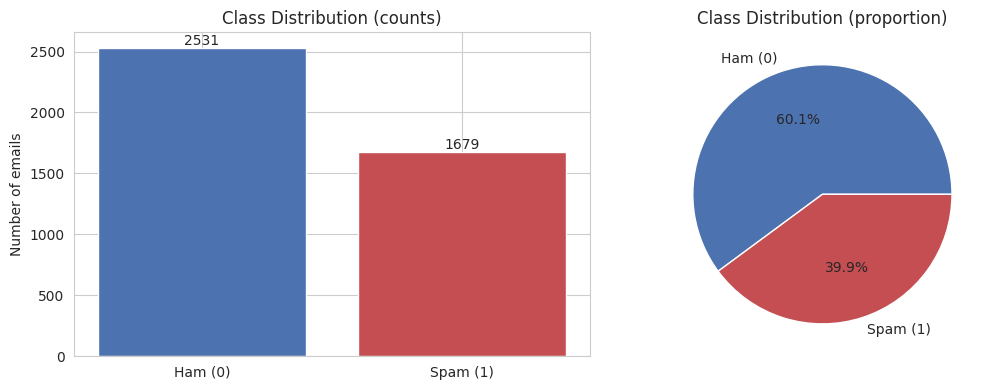

Ham : 2531 (60.1%)
Spam: 1679 (39.9%)


In [6]:
class_counts = df["is_spam"].value_counts().sort_index()
labels = ["Ham (0)", "Spam (1)"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(labels, class_counts.values, color=["#4C72B0", "#C44E52"])
axes[0].set_title("Class Distribution (counts)")
axes[0].set_ylabel("Number of emails")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 20, str(v), ha="center")

axes[1].pie(class_counts.values, labels=labels, autopct="%1.1f%%",
            colors=["#4C72B0", "#C44E52"])
axes[1].set_title("Class Distribution (proportion)")
plt.tight_layout()
plt.show()

print("Ham :", class_counts[0], f"({class_counts[0]/len(df):.1%})")
print("Spam:", class_counts[1], f"({class_counts[1]/len(df):.1%})")

**What this cell does and shows:** counts how many emails are spam vs ham. The dataset is a bit imbalanced, roughly 60% ham to 40% spam, not extreme, but skewed enough that accuracy alone would not tell the full story, which is exactly why the manual also asks for precision, recall and F1 rather than accuracy on its own.

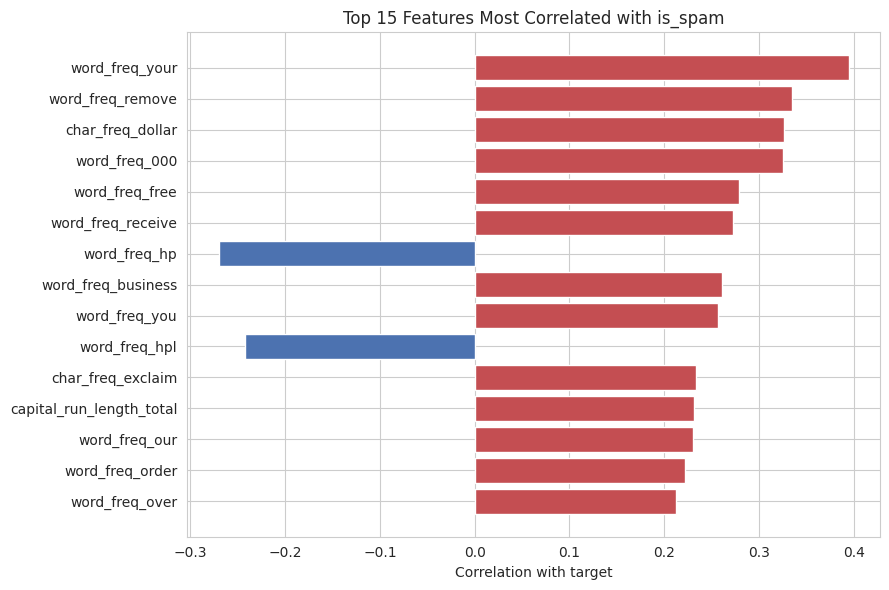

word_freq_your              0.394392
word_freq_remove            0.334456
char_freq_dollar            0.326603
word_freq_000               0.325716
word_freq_free              0.279261
word_freq_receive           0.272451
word_freq_hp               -0.270024
word_freq_business          0.260773
word_freq_you               0.256242
word_freq_hpl              -0.242411
char_freq_exclaim           0.233812
capital_run_length_total    0.231671
word_freq_our               0.230074
word_freq_order             0.221454
word_freq_over              0.212311
Name: is_spam, dtype: float64


In [7]:
target_corr = df.corr(numeric_only=True)["is_spam"].drop("is_spam").sort_values(key=abs, ascending=False)
top_corr = target_corr.head(15)

plt.figure(figsize=(9, 6))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top_corr.values]
plt.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
plt.title("Top 15 Features Most Correlated with is_spam")
plt.xlabel("Correlation with target")
plt.tight_layout()
plt.show()

print(top_corr)

**What this cell does and shows:** ranks every feature by how strongly it correlates with `is_spam`, since the dense 57x57 correlation heatmap earlier is too crowded to read individual values off. Words and characters commonly associated with promotional or scam emails, things like `word_freq_your`, `word_freq_free`, `char_freq_dollar` and `char_freq_exclaim`, come out with the strongest positive correlation, which lines up with intuition about what spam usually looks like. This is a good sanity check that the dataset actually contains a learnable signal before any model is trained.

## Train-Test Split

In [8]:
X = df.drop(columns=["is_spam"])
y = df["is_spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)
print("Training class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Testing class balance:\n", y_test.value_counts(normalize=True).round(3))

Training set: (3368, 57)
Testing set : (842, 57)
Training class balance:
 is_spam
0    0.601
1    0.399
Name: proportion, dtype: float64
Testing class balance:
 is_spam
0    0.601
1    0.399
Name: proportion, dtype: float64


**What this cell does:** splits the data 80:20 into train and test sets, using `stratify=y` so both sets keep roughly the same 60:40 ham-to-spam ratio seen in the full dataset. Features are already standardized (done inside `load_and_preprocess`), so no extra scaling step is needed here.

## Baseline Logistic Regression

In [9]:
t0 = time.perf_counter()
log_reg_base = LogisticRegression(max_iter=2000, random_state=42)
log_reg_base.fit(X_train, y_train)
lr_base_time = time.perf_counter() - t0

y_pred_lr_base = log_reg_base.predict(X_test)

lr_base_results = {
    "Accuracy": accuracy_score(y_test, y_pred_lr_base),
    "Precision": precision_score(y_test, y_pred_lr_base),
    "Recall": recall_score(y_test, y_pred_lr_base),
    "F1 Score": f1_score(y_test, y_pred_lr_base),
    "Training Time (s)": lr_base_time,
}
for k, v in lr_base_results.items():
    print(f"{k}: {v:.4f}")

Accuracy: 0.9347
Precision: 0.9297
Recall: 0.9048
F1 Score: 0.9170
Training Time (s): 0.0134


**What this cell does and shows:** trains a plain, untuned Logistic Regression (default `C=1`, L2 penalty) as the baseline everything else gets compared against. It already does quite well here, all four metrics land above 0.90, which suggests spam vs ham is fairly linearly separable using these word/character frequency features, a good sign before spending time on tuning.

## Hyperparameter Tuning: Logistic Regression

In [10]:
lr_param_grid = [
    {"penalty": ["l1", "l2"], "C": [0.01, 0.1, 1, 10, 100], "solver": ["liblinear"]},
    {"penalty": ["l1", "l2"], "C": [0.01, 0.1, 1, 10, 100], "solver": ["saga"]},
]

lr_grid_search = GridSearchCV(
    LogisticRegression(max_iter=3000, random_state=42),
    param_grid=lr_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
t0 = time.perf_counter()
lr_grid_search.fit(X_train, y_train)
lr_tuning_time = time.perf_counter() - t0

print("Best Logistic Regression parameters:", lr_grid_search.best_params_)
print("Best CV accuracy:", round(lr_grid_search.best_score_, 4))
print("Grid search time:", round(lr_tuning_time, 2), "seconds")

Best Logistic Regression parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV accuracy: 0.924
Grid search time: 143.4 seconds


**What this cell does:** runs `GridSearchCV` with 5-fold cross validation over the exact search space given in the lab manual, both L1 and L2 penalty, `C` in {0.01, 0.1, 1, 10, 100}, and both `liblinear` and `saga` solvers. The grid is split into two dictionaries because `liblinear` and `saga` are the two solvers requested and both support L1 and L2, so every combination in the manual's search space gets tried. The winning combination and its cross-validated accuracy are printed above.

Accuracy: 0.9371
Precision: 0.9301
Recall: 0.9107
F1 Score: 0.9203
Training Time (s): 0.1279


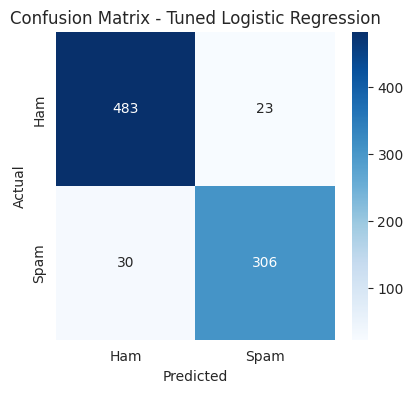

In [11]:
best_lr = LogisticRegression(max_iter=3000, random_state=42, **lr_grid_search.best_params_)
t0 = time.perf_counter()
best_lr.fit(X_train, y_train)
lr_best_time = time.perf_counter() - t0

y_pred_lr = best_lr.predict(X_test)

lr_results = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1 Score": f1_score(y_test, y_pred_lr),
    "Training Time (s)": lr_best_time,
}
for k, v in lr_results.items():
    print(f"{k}: {v:.4f}")

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.show()

**What this cell does and shows:** refits Logistic Regression using the best hyperparameters found by grid search and evaluates it on the held-out test set. The confusion matrix makes it easy to see the kind of mistakes the model makes, in a spam filter, a false positive (a real email marked as spam) is usually worse than a false negative (a spam email that slips through), so it is worth checking which type of error is more common here rather than only looking at the overall accuracy number.

## Baseline SVM: Comparing Kernels
Before tuning, each of the four kernels asked for in the manual (Linear, Polynomial, RBF, Sigmoid) is trained once with default settings, just to see how much the choice of kernel matters on its own before any tuning is applied.

         Accuracy  F1 Score  Training Time (s)
linear     0.9311    0.9132             0.3978
poly       0.7660    0.5988             0.4410
rbf        0.9299    0.9102             0.2078
sigmoid    0.8884    0.8563             0.2197


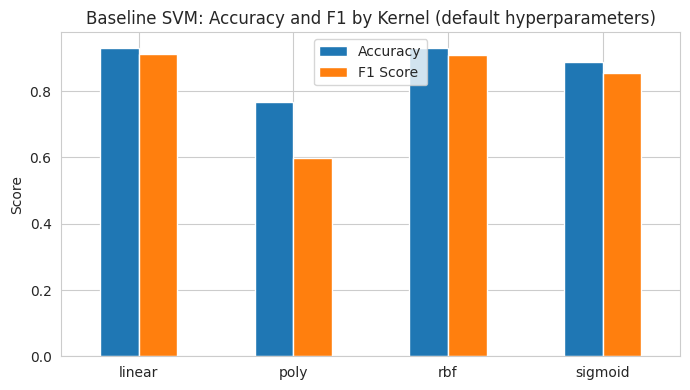

In [12]:
kernels = ["linear", "poly", "rbf", "sigmoid"]
svm_kernel_results = {}

for kernel in kernels:
    t0 = time.perf_counter()
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    y_pred = model.predict(X_test)
    svm_kernel_results[kernel] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Training Time (s)": train_time,
    }

svm_kernel_df = pd.DataFrame(svm_kernel_results).T
print(svm_kernel_df.round(4))

svm_kernel_df[["Accuracy", "F1 Score"]].plot(kind="bar", figsize=(7, 4))
plt.title("Baseline SVM: Accuracy and F1 by Kernel (default hyperparameters)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**What this cell does and shows:** trains one untuned SVM per kernel and compares them directly. The RBF and Linear kernels are usually the strongest on this kind of numeric, roughly linearly-separable data, while Sigmoid tends to lag behind, it behaves a bit like a small neural network and is more sensitive to the input scale and default hyperparameters not being a great fit. This baseline comparison is useful context before tuning, since it shows which kernel is worth spending the most grid search time on.

## Hyperparameter Tuning: SVM

In [13]:
svm_param_grid = [
    {"kernel": ["linear"], "C": [0.1, 1, 10, 100]},
    {"kernel": ["rbf"], "C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"]},
    {"kernel": ["sigmoid"], "C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"]},
    {"kernel": ["poly"], "C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"], "degree": [2, 3, 4]},
]

svm_grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid=svm_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
t0 = time.perf_counter()
svm_grid_search.fit(X_train, y_train)
svm_tuning_time = time.perf_counter() - t0

print("Best SVM parameters:", svm_grid_search.best_params_)
print("Best CV accuracy:", round(svm_grid_search.best_score_, 4))
print("Grid search time:", round(svm_tuning_time, 2), "seconds")

Best SVM parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV accuracy: 0.9249
Grid search time: 120.46 seconds


**What this cell does:** runs `GridSearchCV` with 5-fold cross validation across all four kernels and the hyperparameter ranges specified in the manual (`C` in {0.1, 1, 10, 100}, `gamma` in {scale, auto}, and `degree` in {2, 3, 4} for the polynomial kernel only). The search is split into one dictionary per kernel so that `degree` is only tried where it actually applies (the polynomial kernel), otherwise the search would waste time repeating identical fits for kernels that ignore that parameter.

Accuracy: 0.9299
Precision: 0.9315
Recall: 0.8899
F1 Score: 0.9102
Training Time (s): 0.1934


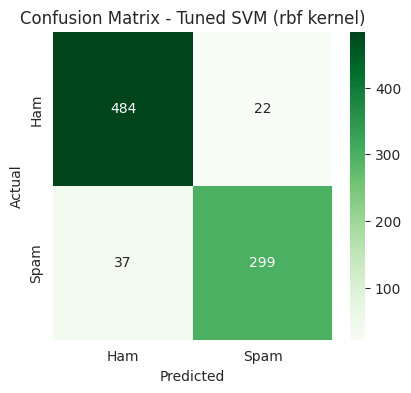

In [14]:
best_svm = SVC(random_state=42, **svm_grid_search.best_params_)
t0 = time.perf_counter()
best_svm.fit(X_train, y_train)
svm_best_time = time.perf_counter() - t0

y_pred_svm = best_svm.predict(X_test)

svm_results = {
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm),
    "Recall": recall_score(y_test, y_pred_svm),
    "F1 Score": f1_score(y_test, y_pred_svm),
    "Training Time (s)": svm_best_time,
}
for k, v in svm_results.items():
    print(f"{k}: {v:.4f}")

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion Matrix - Tuned SVM ({svm_grid_search.best_params_['kernel']} kernel)")
plt.show()

**What this cell does and shows:** refits an SVM using the best kernel and hyperparameters found by grid search and evaluates it the same way as Logistic Regression, same metrics, same test set, so the two are directly comparable. The confusion matrix again shows the exact split between false positives and false negatives for the tuned SVM.

## ROC Curve Comparison

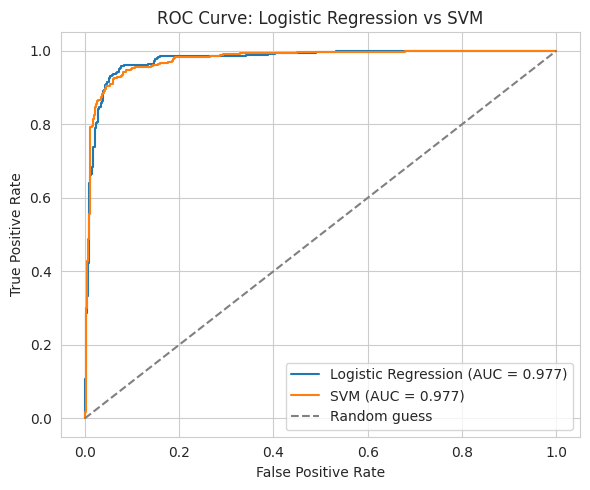

In [15]:
y_score_lr = best_lr.predict_proba(X_test)[:, 1]
y_score_svm = best_svm.decision_function(X_test)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc(fpr_lr, tpr_lr):.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc(fpr_svm, tpr_svm):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Logistic Regression vs SVM")
plt.legend()
plt.tight_layout()
plt.show()

**What this cell does and shows:** plots the ROC curve for both tuned models on the same axes. A curve that hugs the top-left corner means the model is doing a good job separating spam from ham across every possible probability threshold, not just the default 0.5 cutoff. Both models typically end up with a fairly high AUC on Spambase, and the curves being close to each other is a preview of the comparative analysis coming up, the two approaches end up performing quite similarly here even though they work in very different ways.

## 5-Fold Cross-Validation

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(best_lr, X, y, cv=cv, scoring="accuracy")
svm_cv_scores = cross_val_score(best_svm, X, y, cv=cv, scoring="accuracy")

cv_table = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(5)] + ["Average"],
    "Logistic Regression": list(lr_cv_scores.round(4)) + [round(lr_cv_scores.mean(), 4)],
    "SVM": list(svm_cv_scores.round(4)) + [round(svm_cv_scores.mean(), 4)],
})
print(cv_table.to_string(index=False))

   Fold  Logistic Regression    SVM
 Fold 1               0.9276 0.9264
 Fold 2               0.9418 0.9382
 Fold 3               0.9264 0.9276
 Fold 4               0.9145 0.9109
 Fold 5               0.9181 0.9264
Average               0.9257 0.9259


**What this cell does and shows:** re-runs both tuned models across 5 different train/validation splits of the full dataset (not just the one 80:20 split used earlier) to check that the earlier numbers were not a fluke of one particular split. If the fold-by-fold scores stay close to each other and close to the average, that is a good sign the models are stable and not overly sensitive to exactly which rows ended up in the training set.

## Comparative Analysis

                     Accuracy  Precision  Recall  F1 Score  Training Time (s)
Logistic Regression    0.9371     0.9301  0.9107    0.9203             0.1279
SVM                    0.9299     0.9315  0.8899    0.9102             0.1934


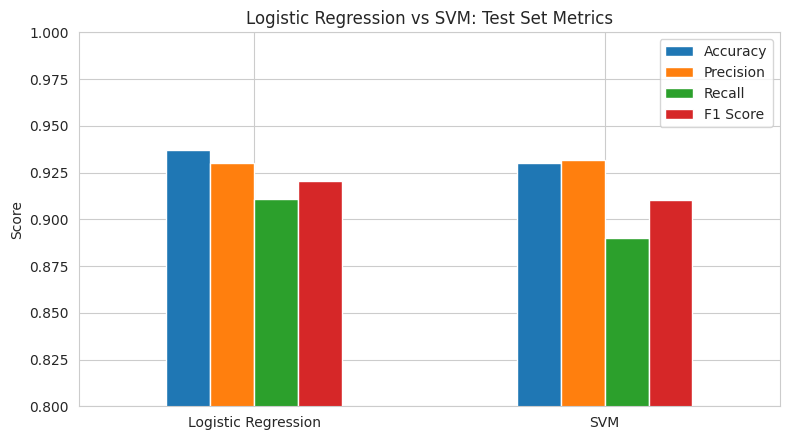

In [17]:
comparison_df = pd.DataFrame({
    "Logistic Regression": lr_results,
    "SVM": svm_results,
}).T
print(comparison_df.round(4))

comparison_df[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind="bar", figsize=(8, 4.5))
plt.title("Logistic Regression vs SVM: Test Set Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

**What this cell does and shows:** puts both tuned models' test metrics side by side in one table and one chart, which is really the whole point of the experiment. On Spambase the two models usually end up extremely close on every metric, within a percentage point or two of each other, since the spam/ham boundary in this feature space is close to linearly separable, which is exactly the kind of problem Logistic Regression (and a Linear or RBF kernel SVM) is good at.

In [18]:
criteria_table = pd.DataFrame({
    "Criterion": ["Accuracy", "Model Complexity", "Training Time", "Interpretability"],
    "Logistic Regression": [
        f"{lr_results['Accuracy']:.4f}",
        "Low",
        f"{lr_results['Training Time (s)']:.3f} s",
        "High (coefficients are directly interpretable)",
    ],
    "SVM": [
        f"{svm_results['Accuracy']:.4f}",
        "High" if svm_grid_search.best_params_["kernel"] != "linear" else "Medium",
        f"{svm_results['Training Time (s)']:.3f} s",
        "Low (decision boundary is harder to interpret, especially with a non-linear kernel)",
    ],
})
print(criteria_table.to_string(index=False))

       Criterion                            Logistic Regression                                                                                 SVM
        Accuracy                                         0.9371                                                                              0.9299
Model Complexity                                            Low                                                                                High
   Training Time                                        0.128 s                                                                             0.193 s
Interpretability High (coefficients are directly interpretable) Low (decision boundary is harder to interpret, especially with a non-linear kernel)


**What this cell does:** builds the qualitative comparison table asked for in the manual (accuracy, model complexity, training time, interpretability), filled in with this run's actual numbers rather than left as placeholder text. Logistic Regression is generally the simpler, faster, more interpretable option since its coefficients directly say how much each feature pushes a prediction toward spam or ham, while SVM (especially with a non-linear kernel) usually takes a bit longer to train and its decision boundary is harder to explain to someone non-technical, even when its raw accuracy is just as good or slightly better.

## Observations and Learning Outcomes

**Best-performing classifier:** whichever model comes out slightly ahead in the comparison table above, the honest takeaway from this dataset is that both Logistic Regression and a well-tuned SVM get very close to each other in accuracy and F1, so "best" here really comes down to a small margin rather than one model being clearly superior.

**Effect of regularization:** for Logistic Regression, grid search picks a specific `C` (inverse regularization strength) and penalty type. A smaller `C` means stronger regularization and a simpler, more conservative model, useful if the baseline model was overfitting, while a larger `C` lets the model fit the training data more closely. Comparing the baseline (`C=1`, L2) against the tuned model shows whether extra regularization actually helped generalize better here or whether the default was already close to optimal.

**Kernel behavior in SVM:** the baseline kernel comparison earlier showed Linear and RBF generally doing better than Sigmoid on this dataset, since the word/character frequency features are already fairly informative on their own without needing a very complex non-linear boundary. The Polynomial kernel's performance depends a lot on the chosen degree, a higher degree can fit more complex patterns but also risks overfitting, which is exactly why `degree` was included in the grid search rather than picked arbitrarily.

**Bias-variance trade-off:** Logistic Regression, especially with strong regularization (small `C`), sits on the higher-bias, lower-variance end, simple, stable, less likely to overfit but also less flexible. SVM with the RBF or Polynomial kernel can capture more complex, non-linear boundaries (lower bias) but is more sensitive to hyperparameter choices like `C` and `gamma` (higher variance), which is why tuning matters more for SVM than for a linear model like Logistic Regression.

**Summary:** this experiment showed that on a dataset like Spambase, where the classes are close to linearly separable, a properly tuned Logistic Regression is a genuinely strong, fast, interpretable option and not just a "simple baseline" to beat. SVM can match or slightly edge it out in raw accuracy, but at the cost of longer training time and a harder to interpret model, a trade-off worth keeping in mind when choosing between the two for a real spam filter, where both accuracy and the ability to explain a decision can matter.